<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6378 entries, 0 to 6377
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6378 non-null   int64
 1   Attendance                  6378 non-null   int64
 2   Parental_Involvement        6378 non-null   int64
 3   Access_to_Resources         6378 non-null   int64
 4   Extracurricular_Activities  6378 non-null   int64
 5   Sleep_Hours                 6378 non-null   int64
 6   Previous_Scores             6378 non-null   int64
 7   Motivation_Level            6378 non-null   int64
 8   Internet_Access             6378 non-null   int64
 9   Tutoring_Sessions           6378 non-null   int64
 10  Family_Income               6378 non-null   int64
 11  Teacher_Quality             6378 non-null   int64
 12  School_Type                 6378 non-null   int64
 13  Peer_Influence              6378 non-null   int64
 14  Physical

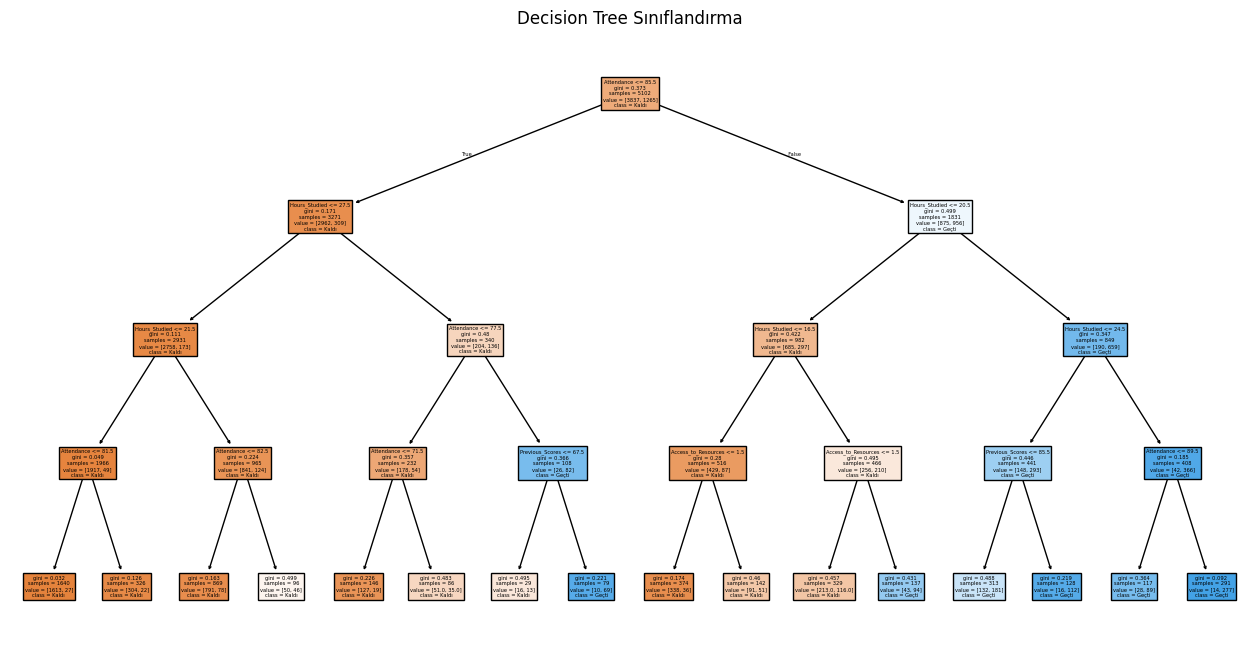

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from meta import *

df = pd.read_csv(savepath + r"/student_eda.csv")

df.info()
df['Pass_Fail'] = (df['Exam_Score'] >= 70).astype(int)

print("Pass/Fail Dağılımı:")
print(df['Pass_Fail'].value_counts())
print("\nOranlar:")
print(df['Pass_Fail'].value_counts(normalize=True) * 100)

X = df.drop(['Exam_Score', 'Pass_Fail'], axis=1)
y = df['Pass_Fail']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nÖzelliklerin listesi:\n{X.columns.tolist()}")

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")
print(f"\nEğitim setinde Pass/Fail oranı:\n{y_train.value_counts()}")
print(f"\nTest setinde Pass/Fail oranı:\n{y_test.value_counts()}")

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,
    min_samples_leaf=5
)

model.fit(X_train, y_train)

print("\nDecision Tree modeli başarıyla eğitildi!")

y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)

print("İlk 10 tahmin:")
print(f"Tahmin edilen sınıflar: {y_pred[:10]}")
print(f"Geçme olasılıkları: {y_pred_proba[:10, 1]}")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANS METRİKLERİ")
print("=" * 50)
print(f"Doğruluk (Accuracy):    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Kesinlik (Precision):   {precision:.4f} ({precision*100:.2f}%)")
print(f"Duyarlılık (Recall):    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Skoru:               {f1:.4f}")
print("\n" + "=" * 50)
print("KARIŞIKLIK MATRİSİ (Confusion Matrix)")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred)
print(f"Doğru Negatif (TN):  {cm[0, 0]}  | Yanlış Pozitif (FP): {cm[0, 1]}")
print(f"Yanlış Negatif (FN): {cm[1, 0]}  | Doğru Pozitif (TP):  {cm[1, 1]}")
print("\n" + "=" * 50)

df['Predicted_Pass_Fail'] = model.predict(X)
df['Pass_Probability'] = model.predict_proba(X)[:, 1]

print("=" * 60)
print("TÜMEL SONUÇLAR - KAÇI GEÇTİ, KAÇI KALDI?")
print("=" * 60)

pass_count = (df['Predicted_Pass_Fail'] == 1).sum()
fail_count = (df['Predicted_Pass_Fail'] == 0).sum()
total_count = len(df)

pass_percent = (pass_count / total_count) * 100
fail_percent = (fail_count / total_count) * 100

print(f"Toplam Öğrenci: {total_count}")
print(f"Geçen:      {pass_count:3d} ({pass_percent:6.2f}%)")
print(f"Kalan:      {fail_count:3d} ({fail_percent:6.2f}%)")

plt.figure(figsize=(16, 8))
tree.plot_tree(model, feature_names=X.columns, class_names=['Kaldı', 'Geçti'], filled=True)
plt.title('Decision Tree Sınıflandırma')
plt.show()
